# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/yutao/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32)

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt")).astype(np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(np.int32)

    # Convert to zero-based labels
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features:", num_features)
print("Number of classes:", num_classes)


X_train shape: (7352, 561)
X_test shape: (2947, 561)
Number of features: 561
Number of classes: 6


## 4. Quick Inspection

In [5]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#



summary_table = pd.DataFrame({
    "class_index": range(num_classes),
    "class_name": class_names,
    "num_training_samples": [np.sum(y_train == i) for i in range(num_classes)]
})

summary_table


,class_index,class_name,num_training_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [8]:
from tensorflow import keras

def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1441 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves

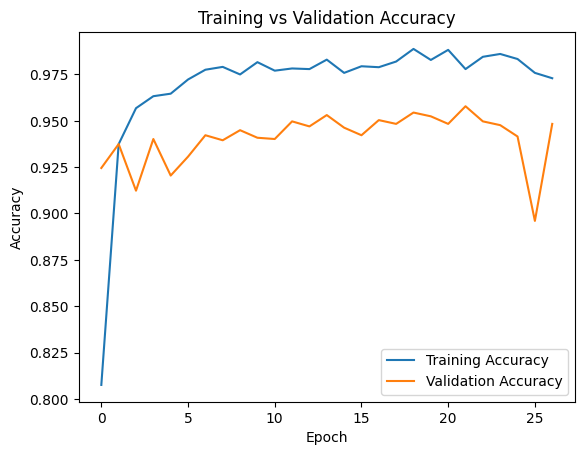

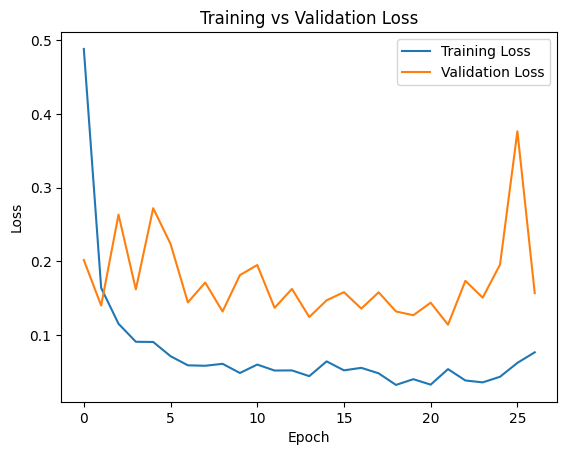

In [10]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#

plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 387us/step
Baseline Test Accuracy: 0.9355276552426196
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.97      0.93      0.95       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.85      0.96      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



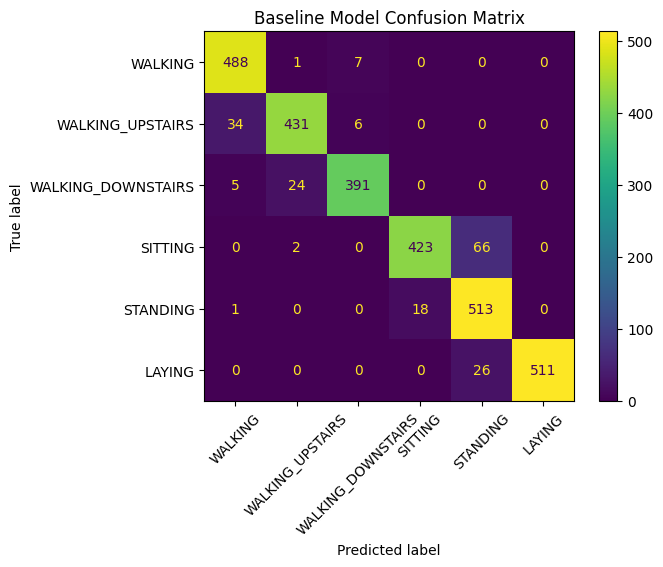

In [11]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_prob = baseline_model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print("Baseline Test Accuracy:", test_accuracy)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Baseline Model Confusion Matrix")
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [12]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        if input_details["dtype"] == np.int8 or input_details["dtype"] == np.uint8:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#

        if output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8:
            output = output_scale * (output.astype(np.float32) - output_zero_point)

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [13]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#

baseline_tflite_fp32 = convert_to_tflite_fp32(baseline_model)

baseline_tflite_fp32_size_kb = save_binary_model(
    baseline_tflite_fp32,
    "baseline_fp32.tflite"
)

baseline_tflite_fp32_accuracy, baseline_tflite_fp32_pred = evaluate_tflite_model(
    baseline_tflite_fp32,
    X_test,
    y_test
)

print("Baseline FP32 TFLite Size (KB):", baseline_tflite_fp32_size_kb)
print("Baseline FP32 TFLite Test Accuracy:", baseline_tflite_fp32_accuracy)


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpggr8hb10/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpggr8hb10/assets
2026-04-23 17:38:50.414443: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.


Baseline FP32 TFLite Size (KB): 726.71875
Baseline FP32 TFLite Test Accuracy: 0.9355276552426196


2026-04-23 17:38:50.414615: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:38:50.416406: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpggr8hb10
2026-04-23 17:38:50.416895: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:38:50.416900: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpggr8hb10
2026-04-23 17:38:50.419507: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 17:38:50.420100: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 17:38:50.445257: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpggr8hb10

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [15]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#

steps_per_epoch = int(np.ceil(0.8 * len(X_train) / batch_size))

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}


# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#

pruned_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.5008 - accuracy: 0.7994 - val_loss: 0.2039 - val_accuracy: 0.9266
Epoch 2/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1693 - accuracy: 0.9376 - val_loss: 0.1715 - val_accuracy: 0.9300
Epoch 3/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1273 - accuracy: 0.9537 - val_loss: 0.1516 - val_accuracy: 0.9320
Epoch 4/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0977 - accuracy: 0.9670 - val_loss: 0.1429 - val_accuracy: 0.9388
Epoch 5/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1371 - accuracy: 0.9532 - val_loss: 0.1361 - val_accuracy: 0.9381
Epoch 6/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1330 - accuracy: 0.9604 - val_loss: 0.1848 - val_accuracy: 0.9313
Epoch 7/12
92/92 [==============================] - 0s 2ms/step - loss: 0.2409 - accuracy: 0.9366 - val_loss: 0.1967 - val_accuracy: 0.9354


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [16]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#

pruned_wrapped_tflite = convert_to_tflite_fp32(pruned_model)

pruned_wrapped_size_kb = save_binary_model(
    pruned_wrapped_tflite,
    "pruned_wrapped_fp32.tflite"
)

pruned_wrapped_accuracy, pruned_wrapped_pred = evaluate_tflite_model(
    pruned_wrapped_tflite,
    X_test,
    y_test
)

stripped_pruned_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(
    stripped_sparse_tflite,
    "stripped_sparse_fp32.tflite"
)

stripped_sparse_accuracy, stripped_sparse_pred = evaluate_tflite_model(
    stripped_sparse_tflite,
    X_test,
    y_test
)

print("Pruned Wrapped FP32 TFLite Size (KB):", pruned_wrapped_size_kb)
print("Pruned Wrapped FP32 TFLite Accuracy:", pruned_wrapped_accuracy)

print("Stripped Sparse FP32 TFLite Size (KB):", stripped_sparse_size_kb)
print("Stripped Sparse FP32 TFLite Accuracy:", stripped_sparse_accuracy)


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpsfra5f4v/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpsfra5f4v/assets
2026-04-23 17:44:08.753724: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:44:08.753987: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:44:08.754555: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpsfra5f4v
2026-04-23 17:44:08.756137: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:44:08.756144: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpsfra5f4v
2026-04-23 17:44:08.762061: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 17:44:08.803657: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpkp4pmjur/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpkp4pmjur/assets
2026-04-23 17:44:10.070399: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:44:10.070414: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:44:10.070536: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpkp4pmjur
2026-04-23 17:44:10.070912: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:44:10.070916: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpkp4pmjur
2026-04-23 17:44:10.071711: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 17:44:10.082818: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned Wrapped FP32 TFLite Size (KB): 1454.21484375
Pruned Wrapped FP32 TFLite Accuracy: 0.9253478113335596
Stripped Sparse FP32 TFLite Size (KB): 424.9609375
Stripped Sparse FP32 TFLite Accuracy: 0.9253478113335596


## 11. Part I Comparison: Accuracy and Model Size

In [17]:
part1_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Pruned with Mask",
        "Stripped Sparse"
    ],
    "Format": [
        "FP32 TFLite",
        "FP32 TFLite",
        "Sparse FP32 TFLite"
    ],
    "Test Accuracy": [
        baseline_tflite_fp32_accuracy,
        pruned_wrapped_accuracy,
        stripped_sparse_accuracy
    ],
    "Model Size (KB)": [
        baseline_tflite_fp32_size_kb,
        pruned_wrapped_size_kb,
        stripped_sparse_size_kb
    ]
})

part1_comparison_df


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.935528,726.718750
1,Pruned with Mask,FP32 TFLite,0.925348,1454.214844
2,Stripped Sparse,Sparse FP32 TFLite,0.925348,424.960938


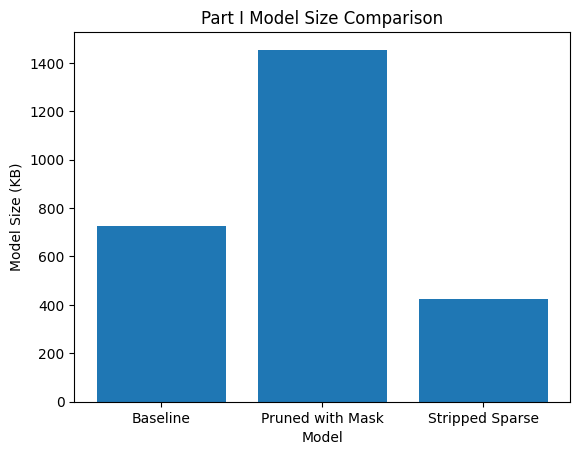

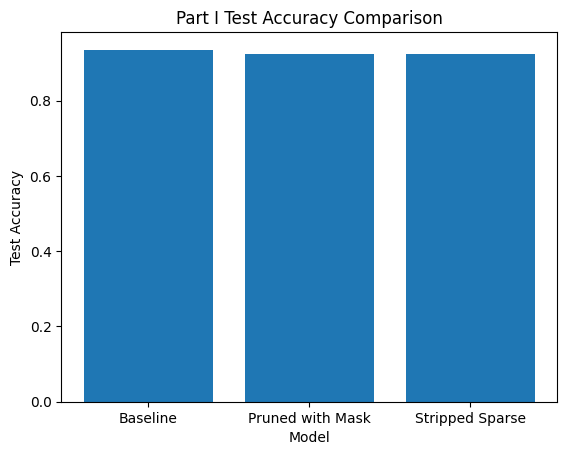

In [18]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#

# 1. Bar chart for model sizes
plt.figure()
plt.bar(part1_comparison_df["Model"], part1_comparison_df["Model Size (KB)"])
plt.xlabel("Model")
plt.ylabel("Model Size (KB)")
plt.title("Part I Model Size Comparison")
plt.show()

# 2. Bar chart for test accuracies
plt.figure()
plt.bar(part1_comparison_df["Model"], part1_comparison_df["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Part I Test Accuracy Comparison")
plt.show()


### Confusion Matrix for the Stripped Sparse Model

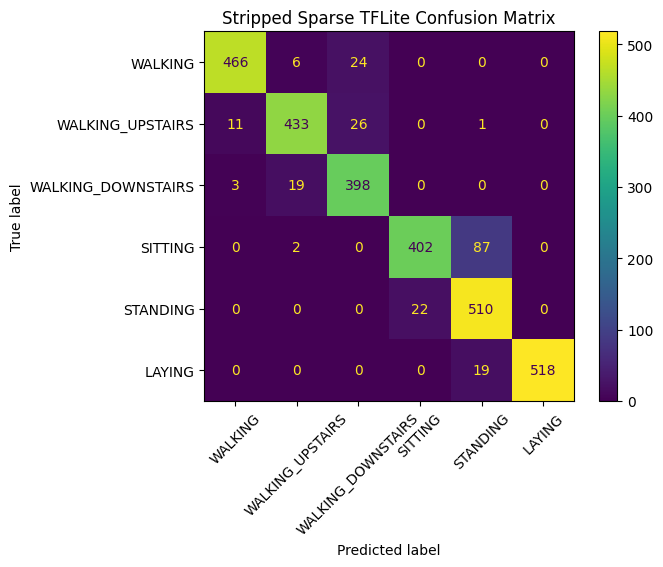

                    precision    recall  f1-score   support

           WALKING       0.97      0.94      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.95      0.82      0.88       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [19]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#

cm = confusion_matrix(y_test, stripped_sparse_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Stripped Sparse TFLite Confusion Matrix")
plt.show()

print(classification_report(
    y_test,
    stripped_sparse_pred,
    target_names=class_names
))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [20]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_mask_float16_tflite = converter.convert()

pruned_mask_float16_size_kb = save_binary_model(
    pruned_mask_float16_tflite,
    "pruned_mask_float16.tflite"
)

pruned_mask_float16_accuracy, pruned_mask_float16_pred = evaluate_tflite_model(
    pruned_mask_float16_tflite,
    X_test,
    y_test
)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter.convert()

stripped_sparse_float16_size_kb = save_binary_model(
    stripped_sparse_float16_tflite,
    "stripped_sparse_float16.tflite"
)

stripped_sparse_float16_accuracy, stripped_sparse_float16_pred = evaluate_tflite_model(
    stripped_sparse_float16_tflite,
    X_test,
    y_test
)

print("Pruned Mask Float16 Size (KB):", pruned_mask_float16_size_kb)
print("Pruned Mask Float16 Accuracy:", pruned_mask_float16_accuracy)

print("Stripped Sparse Float16 Size (KB):", stripped_sparse_float16_size_kb)
print("Stripped Sparse Float16 Accuracy:", stripped_sparse_float16_accuracy)


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp28w96cgc/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp28w96cgc/assets
2026-04-23 17:46:11.834600: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:46:11.834775: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:46:11.835085: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp28w96cgc
2026-04-23 17:46:11.836676: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:46:11.836682: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp28w96cgc
2026-04-23 17:46:11.841969: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 17:46:11.877879: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpjpaw_70q/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpjpaw_70q/assets
2026-04-23 17:46:12.853320: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:46:12.853338: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:46:12.853479: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpjpaw_70q
2026-04-23 17:46:12.853956: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:46:12.853965: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpjpaw_70q
2026-04-23 17:46:12.855261: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 17:46:12.868697: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned Mask Float16 Size (KB): 732.625
Pruned Mask Float16 Accuracy: 0.9253478113335596
Stripped Sparse Float16 Size (KB): 280.0078125
Stripped Sparse Float16 Accuracy: 0.9253478113335596


## 12. Part II Comparison: Accuracy and Model Size

In [21]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#

part2_comparison_df = pd.DataFrame({
    "Model": [
        "Pruned with Mask",
        "Stripped Sparse",
        "Pruned with Mask",
        "Stripped Sparse"
    ],
    "Format": [
        "FP32 TFLite",
        "Sparse FP32 TFLite",
        "Float16 TFLite",
        "Sparse Float16 TFLite"
    ],
    "Test Accuracy": [
        pruned_wrapped_accuracy,
        stripped_sparse_accuracy,
        pruned_mask_float16_accuracy,
        stripped_sparse_float16_accuracy
    ],
    "Model Size (KB)": [
        pruned_wrapped_size_kb,
        stripped_sparse_size_kb,
        pruned_mask_float16_size_kb,
        stripped_sparse_float16_size_kb
    ]
})

part2_comparison_df


,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned with Mask,FP32 TFLite,0.925348,1454.214844
1,Stripped Sparse,Sparse FP32 TFLite,0.925348,424.960938
2,Pruned with Mask,Float16 TFLite,0.925348,732.625000
3,Stripped Sparse,Sparse Float16 TFLite,0.925348,280.007812


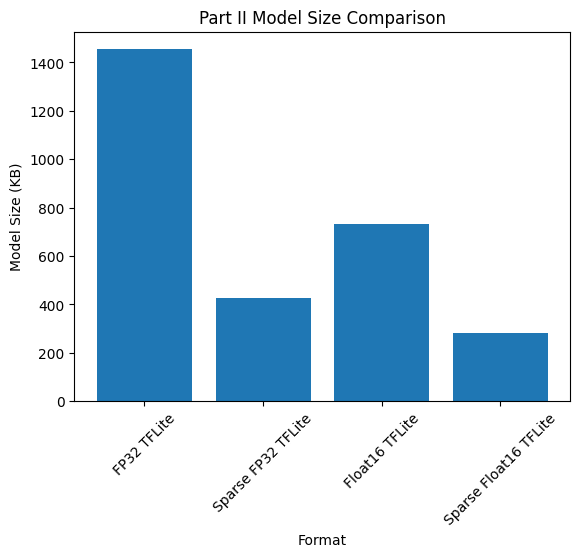

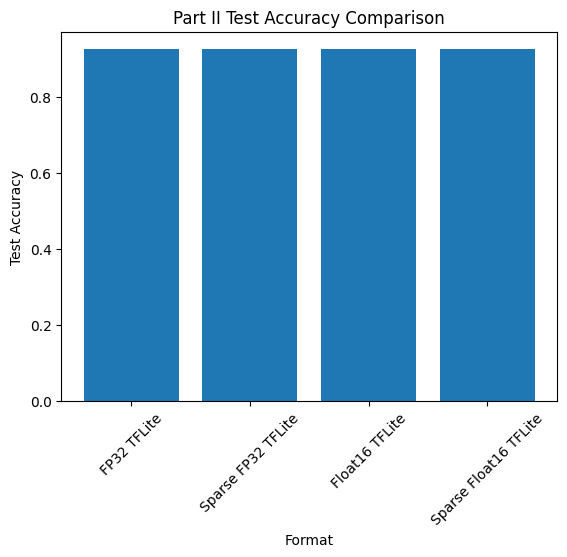

In [22]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#

plt.figure()
plt.bar(part2_comparison_df["Format"], part2_comparison_df["Model Size (KB)"])
plt.xlabel("Format")
plt.ylabel("Model Size (KB)")
plt.title("Part II Model Size Comparison")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(part2_comparison_df["Format"], part2_comparison_df["Test Accuracy"])
plt.xlabel("Format")
plt.ylabel("Test Accuracy")
plt.title("Part II Test Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

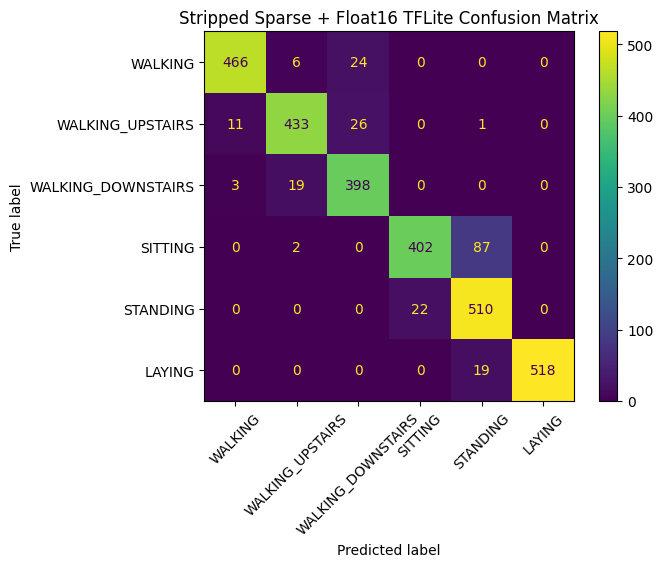

                    precision    recall  f1-score   support

           WALKING       0.97      0.94      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.95      0.82      0.88       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [23]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

cm = confusion_matrix(y_test, stripped_sparse_float16_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Stripped Sparse + Float16 TFLite Confusion Matrix")
plt.show()

print(classification_report(
    y_test,
    stripped_sparse_float16_pred,
    target_names=class_names
))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?

   No. Pruning alone did not reduce the file size when the pruning wrappers were still attached because the masks and             additional metadata are still stored in the model.
   
2. Why does `strip_pruning(...)` matter before export?

   strip_pruning(...) removes the pruning wrappers and masks, leaving only the sparse weights. This allows the model to           actually benefit from sparsity and reduces the final file size.

   
3. Which model had the smallest file size in this notebook?

   The stripped sparse model with float16 quantization had the smallest file size.

   
4. Did float16 quantization noticeably change the test accuracy?

   No. Float16 quantization did not noticeably change the test accuracy; the performance remained very close to the FP32 model.

   
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

   I would choose the stripped sparse + float16 model because it has the smallest file size while maintaining high accuracy,      making it efficient for deployment on resource-constrained devices.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
